[[1.         2.11994793]
 [1.         3.45749223]
 [2.         2.41369623]
 [0.         1.4540836 ]
 [1.         0.9980541 ]
 [1.         3.83500437]
 [2.         2.53359376]
 [0.         1.19249474]
 [1.         3.03400394]
 [1.         3.13964752]
 [2.         1.4819551 ]
 [3.         0.41745057]
 [1.         4.23118523]
 [1.         2.10097807]
 [2.         2.99424023]
 [3.         2.13042379]
 [1.         3.18864688]
 [1.         0.84257746]
 [2.         0.81267988]
 [0.         0.98488356]
 [1.         2.36246237]
 [1.         1.81754107]
 [2.         0.93442591]
 [0.         0.64547128]
 [1.         2.0072814 ]
 [1.         1.83243647]
 [2.         0.56551684]
 [0.         0.43273179]
 [1.         2.31430484]
 [1.         3.4549734 ]
 [2.         2.42938256]
 [0.         0.63692136]
 [1.         2.08544788]
 [1.         3.3913904 ]
 [2.         2.28858348]
 [3.         0.35348474]
 [1.         2.91149348]
 [1.         1.12094299]
 [2.         0.1155073 ]
 [0.         0.52200507]


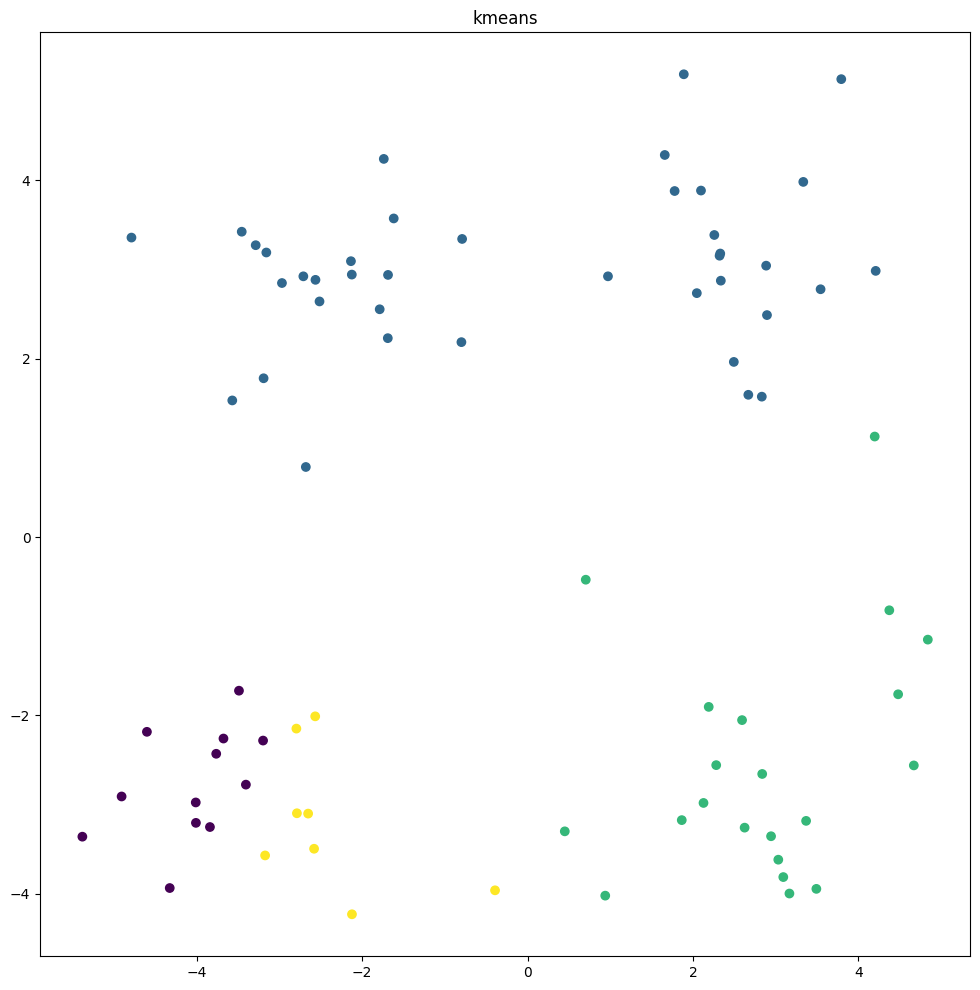

In [2]:
# encoding:utf-8
# 自己实现 KMeans 算法实现

import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 12))


def loadDataSet(fileName):
    '''
         list集合
    '''
    dataMat = []
    fr = open(fileName)
    for line in fr.readlines():
        curLine = line.strip().split('\t')
        fltLine = list(map(float, curLine))
        dataMat.append(fltLine)
    return dataMat

# 计算两个样本之间的距离（欧式距离）
def distEclud(vecA, vecB):
    return np.sqrt(np.sum(np.power(vecA - vecB, 2)))


'''
    随机选取K个中心点的坐标
'''
def randCent(dataSet, k):
    # n=2
    n = np.shape(dataSet)[1]
    '''
        centroids是一个3*2的矩阵，用于存储k个中心点的坐标
    '''
    centroids = np.mat(np.zeros((k, n)))
    for j in range(n):
        minJ = np.min(dataSet[:, j])
        rangeJ = np.max(dataSet[:, j]) - minJ
        centroids[:, j] = np.mat(minJ + rangeJ * np.random.rand(k, 1))
    return centroids


def kMeans(dataSet, k, distMeas=distEclud, createCent=randCent):
    # 获取矩阵的形状    80*2
    m = np.shape(dataSet)[0]
    # 创建一个80*2零矩阵
    clusterAssment = np.mat(np.zeros((m, 2)))
    #     createCent找到K个随机中心点（虚拟的中心点）
    centroids = createCent(dataSet, k)
    # 控制迭代
    clusterChanged = True

    while clusterChanged:
        clusterChanged = False
        for i in range(m):
            minDist = np.inf
            minIndex = -1
            # 遍历K个中心点
            for j in range(k):
                # 取的第二个中心点
                x = centroids[j, :]
                # 第一个样本与第二个中心点的距离 欧式距离
                distJI = distMeas(x, dataSet[i, :])
                if distJI < minDist:
                    minDist = distJI
                    minIndex = j

            if clusterAssment[i, 0] != minIndex: clusterChanged = True
            clusterAssment[i, :] = minIndex, minDist
            # 更新每一类的新的中心点坐标
        for cent in range(k):
            # nonzero返回符合条件的数据的索引值
            ptsInClust = dataSet[np.nonzero(clusterAssment[:, 0].A == cent)[0]]
            centroids[cent, :] = np.mean(ptsInClust, axis=0)
    #         centroids最终聚类完的中心点坐标     clusterAssment记录每一条样本的分类以及与当前类的中心点的距离
    return centroids, clusterAssment


if __name__ == '__main__':
    dataMat = np.mat(loadDataSet('testSet.txt'))
    k = 4
    centroids, clusterAssment = kMeans(dataMat, k, distMeas=distEclud, createCent=randCent)
    print(clusterAssment)
    print(centroids)


    # 将聚类的结果 使用散点图的形式展现出来    matplotlib
    dataMat = np.array(dataMat)
    # 存储是每一个样本的分类号  plt理解成就是一个画布
    y_pred1 = np.array([int(i) for j in clusterAssment[:, 0].A for i in j])
    plt.scatter(dataMat[:, 0], dataMat[:, 1], c=y_pred1)
    plt.title("kmeans")
    plt.show()

[[-5.19811282e+00  6.41869316e-01]
 [-5.75229538e+00  4.18627111e-01]
 [-1.08448984e+01 -7.55352273e+00]
 ...
 [ 1.36105255e+00 -9.07491863e-01]
 [-3.54141108e-01  7.12241630e-01]
 [ 1.88577252e+00  1.41185693e-03]] [1 1 0 ... 2 2 2]
[0 3 2 1 0 3 2 1 0 3 2 1 0 3 2 1 0 3 2 1 0 3 2 1 0 3 2 1 0 3 2 1 0 3 2 1 0
 3 2 1 0 3 2 1 0 3 2 1 0 3 2 1 0 3 2 1 0 3 2 1 0 3 2 1 0 3 2 1 0 3 2 1 0 3
 2 1 0 3 2 1]


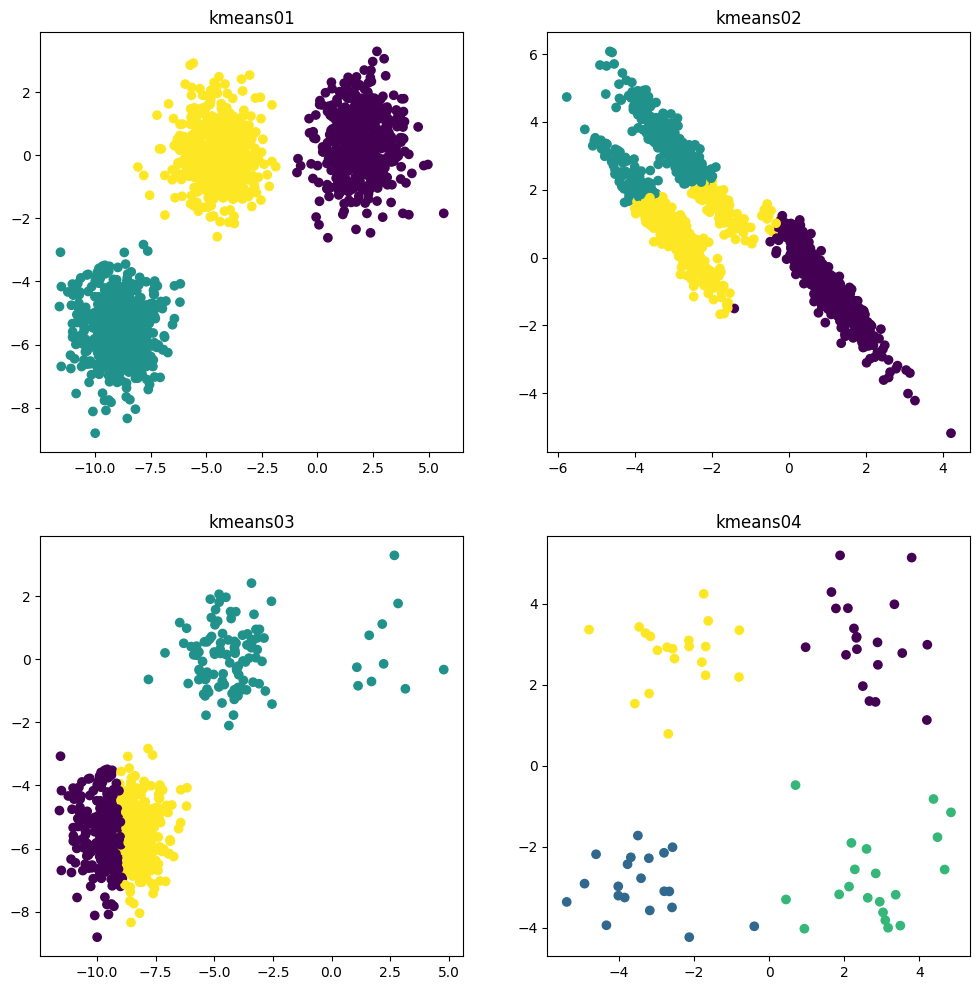

In [3]:
# coding:utf-8  

import numpy as np       
import matplotlib.pyplot as plt       
from sklearn.cluster import KMeans        
from sklearn.datasets import make_blobs  

# 设置画布的大小
plt.figure(figsize=(12, 12))

n_samples = 1500
random_state = 170
'''
    make_blobs函数是为聚类产生数据集 
    产生一个数据集和相应的标签 
    n_samples:表示数据样本点个数,默认值100 
    n_features:表示数据的维度，默认值是2 
    centers:产生数据的中心点，默认值3 
    shuffle ：洗乱，默认值是True 
    random_state:随机生成器的种子  固定值  
'''
x,y = make_blobs(n_samples=n_samples, random_state=random_state)
print(x,y)

y_pred = KMeans(n_clusters=3, random_state=random_state).fit_predict(x)
# plt画布  子画布
plt.subplot(221)     
plt.scatter(x[:, 0], x[:, 1], c=y_pred)    
plt.title("kmeans01")
plt.savefig("kmeans01.png")


# 将随机产生的数据，做了一些变换,基于变换后的数据进行聚类   玩!!!
transformation = [[ 0.60834549, -0.63667341], [-0.40887718, 0.85253229]]
X_aniso = np.dot(x, transformation)
y_pred = KMeans(n_clusters=3, random_state=random_state).fit_predict(X_aniso)
plt.subplot(222)
plt.scatter(X_aniso[:, 0], X_aniso[:, 1], c=y_pred)
plt.title("kmeans02")
#
# #
# #
# #
X_filtered = np.vstack((x[y == 0][:500], x[y == 1][:100], x[y == 2][:10]))
y_pred = KMeans(n_clusters=3, random_state=random_state).fit_predict(X_filtered)
plt.subplot(223)
plt.scatter(X_filtered[:, 0], X_filtered[:, 1], c=y_pred)
plt.title("kmeans03")
#
# #
# #
dataMat = []
fr = open("testSet.txt","r")
for line in fr.readlines():
    if line.strip() != "":
        curLine = line.strip().split('\t')
        fltLine = list(map(float,curLine))
        dataMat.append(fltLine)
dataMat = np.array(dataMat)
y_pred = KMeans(n_clusters=4, random_state=random_state).fit_predict(dataMat)
print(y_pred)

plt.subplot(224)
plt.scatter(dataMat[:, 0], dataMat[:, 1], c=y_pred)
plt.title("kmeans04")
plt.show()